In [1]:
import torch
import re
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

try:
    import editdistance  # type: ignore[import-not-found]
except ImportError:
    editdistance = None

# --- CONFIGURATION ---
BASE_MODEL_ID = "Qwen/Qwen3.5-4B"
ADAPTER_PATH = "./qwen-mathbridge-qlora/final" 
DATASET_ID = "Kyudan/MathBridge"
DATASET_SPLIT = "train"
SHUFFLE_SEED = 42
NUM_EVAL_SAMPLES = 100

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Premier essai: création de colonnes pour étudier la complexité de chaque expression

In [3]:
"""Charge, mélange et échantillonne le dataset d'évaluation."""
dataset = load_dataset(DATASET_ID, split=DATASET_SPLIT)
dataset = dataset.shuffle(seed=SHUFFLE_SEED)
sample_count = min(NUM_EVAL_SAMPLES, len(dataset))

In [5]:
df = dataset.to_pandas()


In [6]:
import re

In [7]:
import pandas as pd

In [8]:
def add_latex_complexity_columns(df, latex_column='equation'):
    """
    Add complexity measurement columns for LaTeX expressions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing LaTeX expressions
    latex_column : str
        Name of the column containing LaTeX expressions
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with new complexity columns added
    """
    
    def extract_latex_expr(text):
        """Extract LaTeX expressions from text"""
        if pd.isna(text):
            return []
        expressions = re.findall(r'\$[^$]+\$', str(text))
        return expressions
    
    def clean_expr(expr):
        """Remove $ delimiters"""
        return re.sub(r'^\$+|\$+$', '', expr)
    
    def count_symbols(expr):
        """Count various symbol types"""
        commands = len(re.findall(r'\\[a-zA-Z]+', expr))
        operators = len(re.findall(r'[+\-*/=<>]', expr))
        braces = expr.count('{') + expr.count('}')
        subscripts = expr.count('_')
        superscripts = expr.count('^')
        
        return {
            'commands': commands,
            'operators': operators,
            'braces': braces,
            'subscripts': subscripts,
            'superscripts': superscripts
        }
    
    def calc_nesting_depth(expr):
        """Calculate maximum nesting depth"""
        max_depth = 0
        current_depth = 0
        
        for char in expr:
            if char == '{':
                current_depth += 1
                max_depth = max(max_depth, current_depth)
            elif char == '}':
                current_depth -= 1
        
        return max_depth
    
    def calc_complexity_score(expr):
        """Calculate comprehensive complexity score"""
        length = len(expr)
        depth = calc_nesting_depth(expr)
        
        symbols = count_symbols(expr)
        unique_commands = len(set(re.findall(r'\\[a-zA-Z]+', expr)))
        
        score = (
            length * 0.1 +
            depth * 2 +
            unique_commands * 1.5 +
            symbols['operators'] * 0.5 +
            (symbols['subscripts'] + symbols['superscripts']) * 1
        )
        
        return score
    
    def process_row(text):
        """Process a single row and return all metrics"""
        if pd.isna(text):
            return {
                'num_expressions': 0,
                'total_length': 0,
                'avg_length': 0,
                'max_length': 0,
                'total_commands': 0,
                'avg_commands': 0,
                'total_operators': 0,
                'avg_operators': 0,
                'total_nesting_depth': 0,
                'max_nesting_depth': 0,
                'avg_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'max_complexity_score': 0,
                'min_complexity_score': 0,
            }
        
        expressions = extract_latex_expr(text)
        
        if not expressions:
            return {
                'num_expressions': 0,
                'total_length': 0,
                'avg_length': 0,
                'max_length': 0,
                'total_commands': 0,
                'avg_commands': 0,
                'total_operators': 0,
                'avg_operators': 0,
                'total_nesting_depth': 0,
                'max_nesting_depth': 0,
                'avg_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'max_complexity_score': 0,
                'min_complexity_score': 0,
            }
        
        num_expr = len(expressions)
        lengths = []
        all_commands = 0
        all_operators = 0
        nesting_depths = []
        all_subscripts = 0
        all_superscripts = 0
        all_braces = 0
        complexity_scores = []
        
        for expr in expressions:
            clean = clean_expr(expr)
            
            # Length
            lengths.append(len(clean))
            
            # Symbol counts
            symbols = count_symbols(clean)
            all_commands += symbols['commands']
            all_operators += symbols['operators']
            all_subscripts += symbols['subscripts']
            all_superscripts += symbols['superscripts']
            all_braces += symbols['braces']
            
            # Nesting depth
            depth = calc_nesting_depth(clean)
            nesting_depths.append(depth)
            
            # Complexity score
            score = calc_complexity_score(clean)
            complexity_scores.append(score)
        
        return {
            'num_expressions': num_expr,
            'total_length': sum(lengths),
            'avg_length': sum(lengths) / num_expr if num_expr > 0 else 0,
            'max_length': max(lengths) if lengths else 0,
            'total_commands': all_commands,
            'avg_commands': all_commands / num_expr if num_expr > 0 else 0,
            'total_operators': all_operators,
            'avg_operators': all_operators / num_expr if num_expr > 0 else 0,
            'total_nesting_depth': sum(nesting_depths),
            'max_nesting_depth': max(nesting_depths) if nesting_depths else 0,
            'avg_nesting_depth': sum(nesting_depths) / num_expr if num_expr > 0 else 0,
            'total_subscripts': all_subscripts,
            'total_superscripts': all_superscripts,
            'total_braces': all_braces,
            'avg_complexity_score': sum(complexity_scores) / num_expr if complexity_scores else 0,
            'max_complexity_score': max(complexity_scores) if complexity_scores else 0,
            'min_complexity_score': min(complexity_scores) if complexity_scores else 0,
        }
    
    # Apply to all rows
    print("Processing LaTeX expressions...")
    metrics = df[latex_column].apply(process_row)
    metrics_df = pd.DataFrame(list(metrics))
    
    # Add all columns to original dataframe
    for col in metrics_df.columns:
        df[f'latex_{col}'] = metrics_df[col]
    
    print(f"✓ Added {len(metrics_df.columns)} new columns")
    print("\nNew columns:")
    for col in sorted(metrics_df.columns):
        print(f"  - latex_{col}")
    
    return df

# Usage
df = add_latex_complexity_columns(df, latex_column='equation')

# View the new columns
print("\nSample data:")
print(df[[
    'equation',
    'latex_num_expressions',
    'latex_avg_length',
    'latex_max_nesting_depth',
    'latex_avg_complexity_score'
]].head())

# Get statistics
print("\nComplexity Statistics:")
print(df[[col for col in df.columns if col.startswith('latex_')]].describe())

Processing LaTeX expressions...
✓ Added 17 new columns

New columns:
  - latex_avg_commands
  - latex_avg_complexity_score
  - latex_avg_length
  - latex_avg_nesting_depth
  - latex_avg_operators
  - latex_max_complexity_score
  - latex_max_length
  - latex_max_nesting_depth
  - latex_min_complexity_score
  - latex_num_expressions
  - latex_total_braces
  - latex_total_commands
  - latex_total_length
  - latex_total_nesting_depth
  - latex_total_operators
  - latex_total_subscripts
  - latex_total_superscripts

Sample data:
                                equation  latex_num_expressions  \
0                                $ 1/R $                      1   
1                                  $ m $                      1   
2  $ |B ( p_B ) \rangle\to |p_b\rangle $                      1   
3                           $ \epsilon $                      1   
4                $ j^ * ( \gamma ) = 0 $                      1   

   latex_avg_length  latex_max_nesting_depth  latex_avg_complexity_

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_latex_complexity_distribution(df, figsize=(18, 12)):
    """
    Plot distributions of all LaTeX complexity columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with latex_* columns
    figsize : tuple
        Figure size (width, height)
    """
    
    # Get all latex columns
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    
    # Create subplots
    n_cols = 4
    n_rows = (len(latex_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten to 1D array for easier indexing
    
    # Set style
    sns.set_style("whitegrid")
    
    for idx, col in enumerate(latex_cols):
        ax = axes[idx]
        
        # Plot histogram with KDE
        data = df[col].dropna()
        
        ax.hist(data, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.grid(True, alpha=0.3)
        
        # Add statistics text
        stats_text = f"Mean: {data.mean():.2f}\nMedian: {data.median():.2f}\nMax: {data.max():.2f}"
        ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, 
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide extra subplots
    for idx in range(len(latex_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('latex_complexity_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Plot saved as 'latex_complexity_distribution.png'")

# Usage
#plot_latex_complexity_distribution(df)

In [3]:
def plot_latex_complexity_correlation(df, figsize=(14, 12)):
    """
    Plot correlation matrix of all LaTeX complexity columns.
    """
    
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    
    # Calculate correlation
    corr_matrix = df[latex_cols].corr()
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(corr_matrix, 
                annot=True,                    # Show correlation values
                fmt='.2f',                     # 2 decimal places
                cmap='RdBu_r',                 # Red-Blue diverging colormap
                center=0,                      # Center at 0
                square=True,                   # Square cells
                linewidths=0.5,                # Cell borders
                cbar_kws={'label': 'Correlation Coefficient'},
                xticklabels=[c.replace('latex_', '') for c in latex_cols],
                yticklabels=[c.replace('latex_', '') for c in latex_cols],
                ax=ax,
                vmin=-1, vmax=1)               # Scale from -1 to 1
    
    ax.set_title('LaTeX Complexity Metrics - Correlation Heatmap', 
                 fontsize=16, fontweight='bold', pad=20)
    
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig('latex_complexity_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Correlation heatmap saved as 'latex_complexity_correlation_heatmap.png'")

# Usage
# plot_latex_complexity_correlation(df)

# Deuxième essai: restriction aux colonnes intéressantes

In [4]:
"""Charge, mélange et échantillonne le dataset d'évaluation."""
dataset = load_dataset(DATASET_ID, split=DATASET_SPLIT)
dataset = dataset.shuffle(seed=SHUFFLE_SEED)
sample_count = min(NUM_EVAL_SAMPLES, len(dataset))

In [5]:
df_2 = dataset.to_pandas()


In [6]:
import re
import pandas as pd

def simplified_add_latex_complexity_columns(df, latex_column='equation'):
    """
    Add complexity measurement columns for LaTeX expressions.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing LaTeX expressions
    latex_column : str
        Name of the column containing LaTeX expressions
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with 9 new complexity columns added
    """
    
    def extract_latex_expr(text):
        """Extract LaTeX expressions from text"""
        if pd.isna(text):
            return []
        expressions = re.findall(r'\$[^$]+\$', str(text))
        return expressions
    
    def clean_expr(expr):
        """Remove $ delimiters"""
        return re.sub(r'^\$+|\$+$', '', expr)
    
    def count_symbols(expr):
        """Count various symbol types"""
        commands = len(re.findall(r'\\[a-zA-Z]+', expr))
        operators = len(re.findall(r'[+\-*/=<>]', expr))
        braces = expr.count('{') + expr.count('}')
        subscripts = expr.count('_')
        superscripts = expr.count('^')
        
        return {
            'commands': commands,
            'operators': operators,
            'braces': braces,
            'subscripts': subscripts,
            'superscripts': superscripts
        }
    
    def calc_nesting_depth(expr):
        """Calculate maximum nesting depth"""
        max_depth = 0
        current_depth = 0
        
        for char in expr:
            if char == '{':
                current_depth += 1
                max_depth = max(max_depth, current_depth)
            elif char == '}':
                current_depth -= 1
        
        return max_depth
    
    def calc_complexity_score(expr):
        """Calculate comprehensive complexity score"""
        length = len(expr)
        depth = calc_nesting_depth(expr)
        
        symbols = count_symbols(expr)
        unique_commands = len(set(re.findall(r'\\[a-zA-Z]+', expr)))
        
        score = (
            length * 0.1 +
            depth * 2 +
            unique_commands * 1.5 +
            symbols['operators'] * 0.5 +
            (symbols['subscripts'] + symbols['superscripts']) * 1
        )
        
        return score
    
    def process_row(text):
        """Process a single row and return 9 metrics"""
        if pd.isna(text):
            return {
                'num_expressions': 0,
                'total_length': 0,
                'total_commands': 0,
                'total_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'total_operators': 0,
            }
        
        expressions = extract_latex_expr(text)
        
        if not expressions:
            return {
                'num_expressions': 0,
                'total_length': 0,
                'total_commands': 0,
                'total_nesting_depth': 0,
                'total_subscripts': 0,
                'total_superscripts': 0,
                'total_braces': 0,
                'avg_complexity_score': 0,
                'total_operators': 0,
            }
        
        num_expr = len(expressions)
        total_length = 0
        all_commands = 0
        all_operators = 0
        total_nesting_depth = 0
        all_subscripts = 0
        all_superscripts = 0
        all_braces = 0
        complexity_scores = []
        
        for expr in expressions:
            clean = clean_expr(expr)
            
            # Length
            total_length += len(clean)
            
            # Symbol counts
            symbols = count_symbols(clean)
            all_commands += symbols['commands']
            all_operators += symbols['operators']
            all_subscripts += symbols['subscripts']
            all_superscripts += symbols['superscripts']
            all_braces += symbols['braces']
            
            # Nesting depth
            depth = calc_nesting_depth(clean)
            total_nesting_depth += depth
            
            # Complexity score
            score = calc_complexity_score(clean)
            complexity_scores.append(score)
        
        return {
            'num_expressions': num_expr,
            'total_length': total_length,
            'total_commands': all_commands,
            'total_nesting_depth': total_nesting_depth,
            'total_subscripts': all_subscripts,
            'total_superscripts': all_superscripts,
            'total_braces': all_braces,
            'avg_complexity_score': sum(complexity_scores) / num_expr if complexity_scores else 0,
            'total_operators': all_operators,
        }
    
    # Apply to all rows
    print("Processing LaTeX expressions...")
    metrics = df[latex_column].apply(process_row)
    metrics_df = pd.DataFrame(list(metrics))
    
    # Add all columns to original dataframe
    for col in metrics_df.columns:
        df[f'latex_{col}'] = metrics_df[col]
    
    print(f"✓ Added {len(metrics_df.columns)} new columns")
    print("\nNew columns (9 total):")
    for col in sorted(metrics_df.columns):
        print(f"  - latex_{col}")
    
    return df

# Usage
df_2 = simplified_add_latex_complexity_columns(df_2, latex_column='equation')

Processing LaTeX expressions...
✓ Added 9 new columns

New columns (9 total):
  - latex_avg_complexity_score
  - latex_num_expressions
  - latex_total_braces
  - latex_total_commands
  - latex_total_length
  - latex_total_nesting_depth
  - latex_total_operators
  - latex_total_subscripts
  - latex_total_superscripts


In [7]:
df_2.columns

Index(['context_before', 'equation', 'context_after', 'spoken_English',
       'latex_num_expressions', 'latex_total_length', 'latex_total_commands',
       'latex_total_nesting_depth', 'latex_total_subscripts',
       'latex_total_superscripts', 'latex_total_braces',
       'latex_avg_complexity_score', 'latex_total_operators'],
      dtype='object')

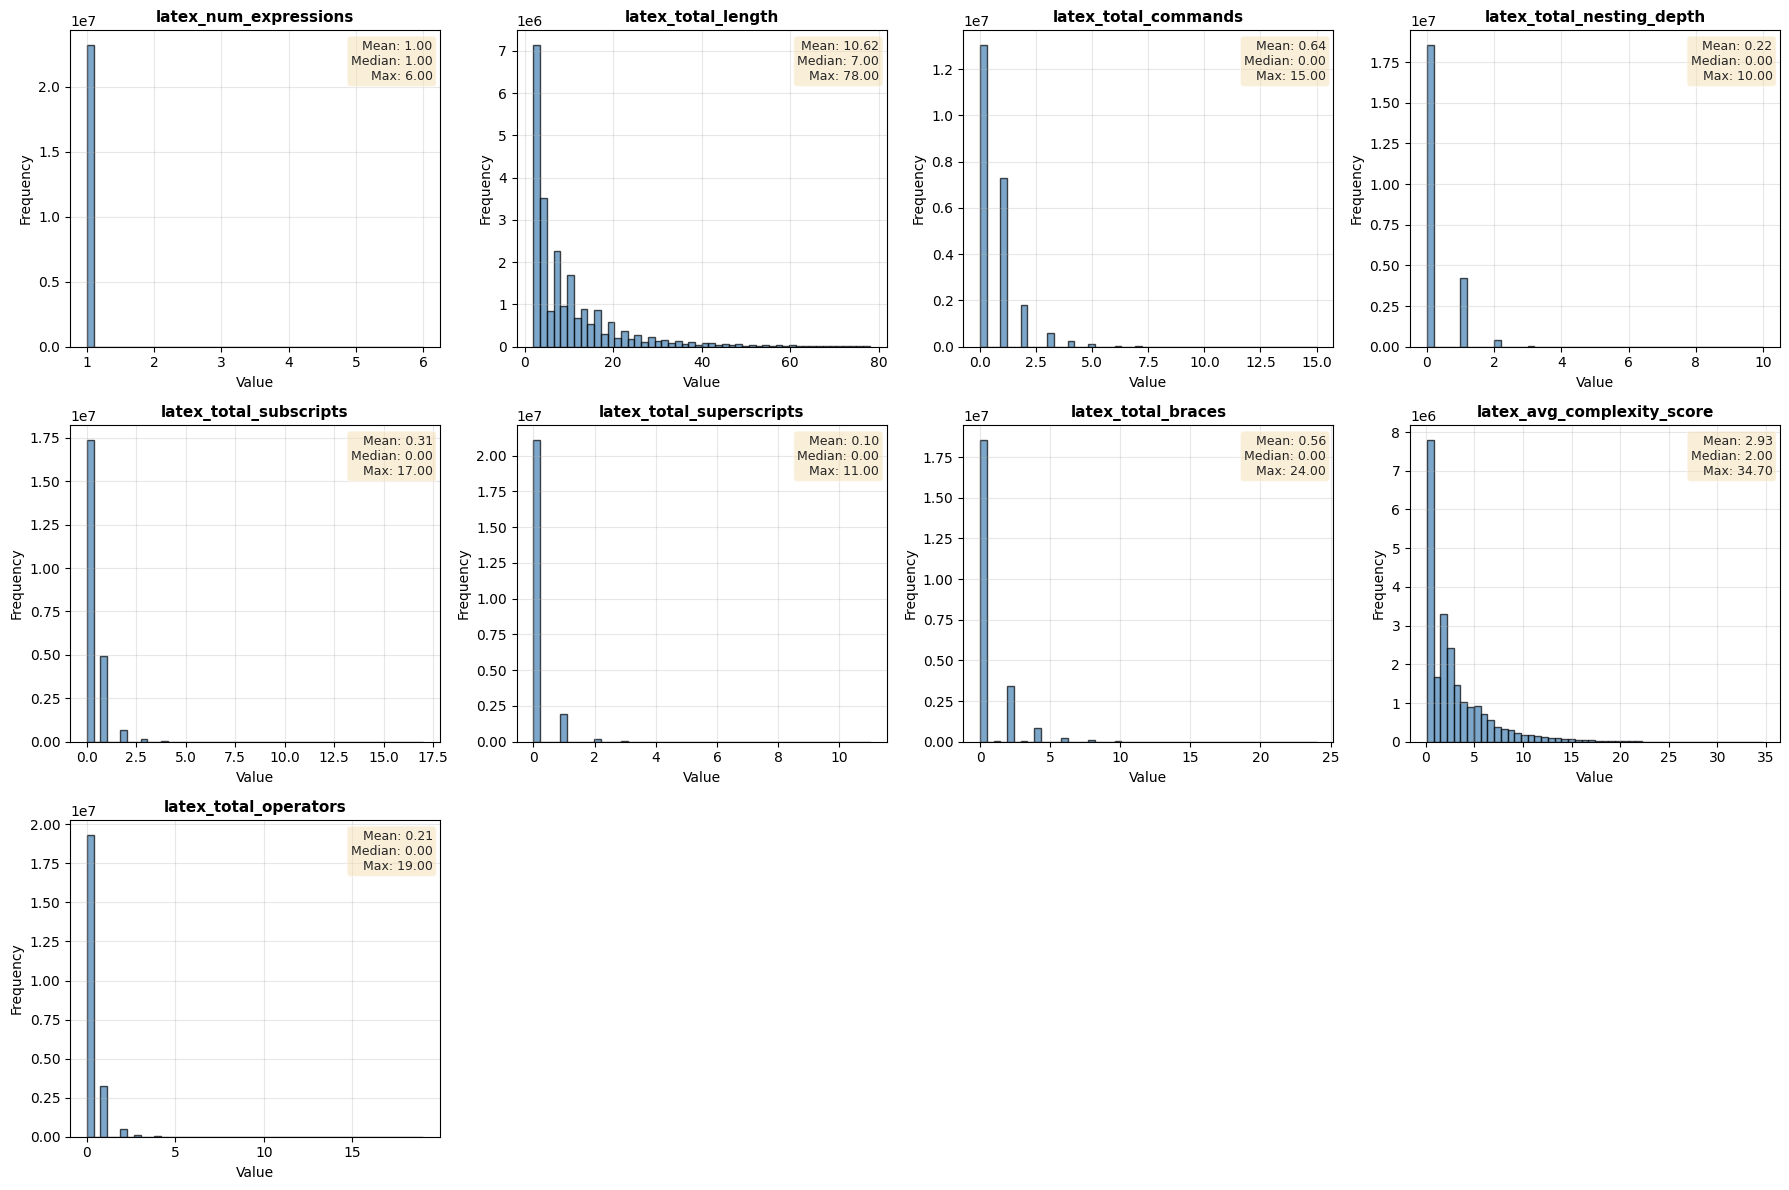

✓ Plot saved as 'latex_complexity_distribution.png'


In [8]:
# Usage
plot_latex_complexity_distribution(df_2)

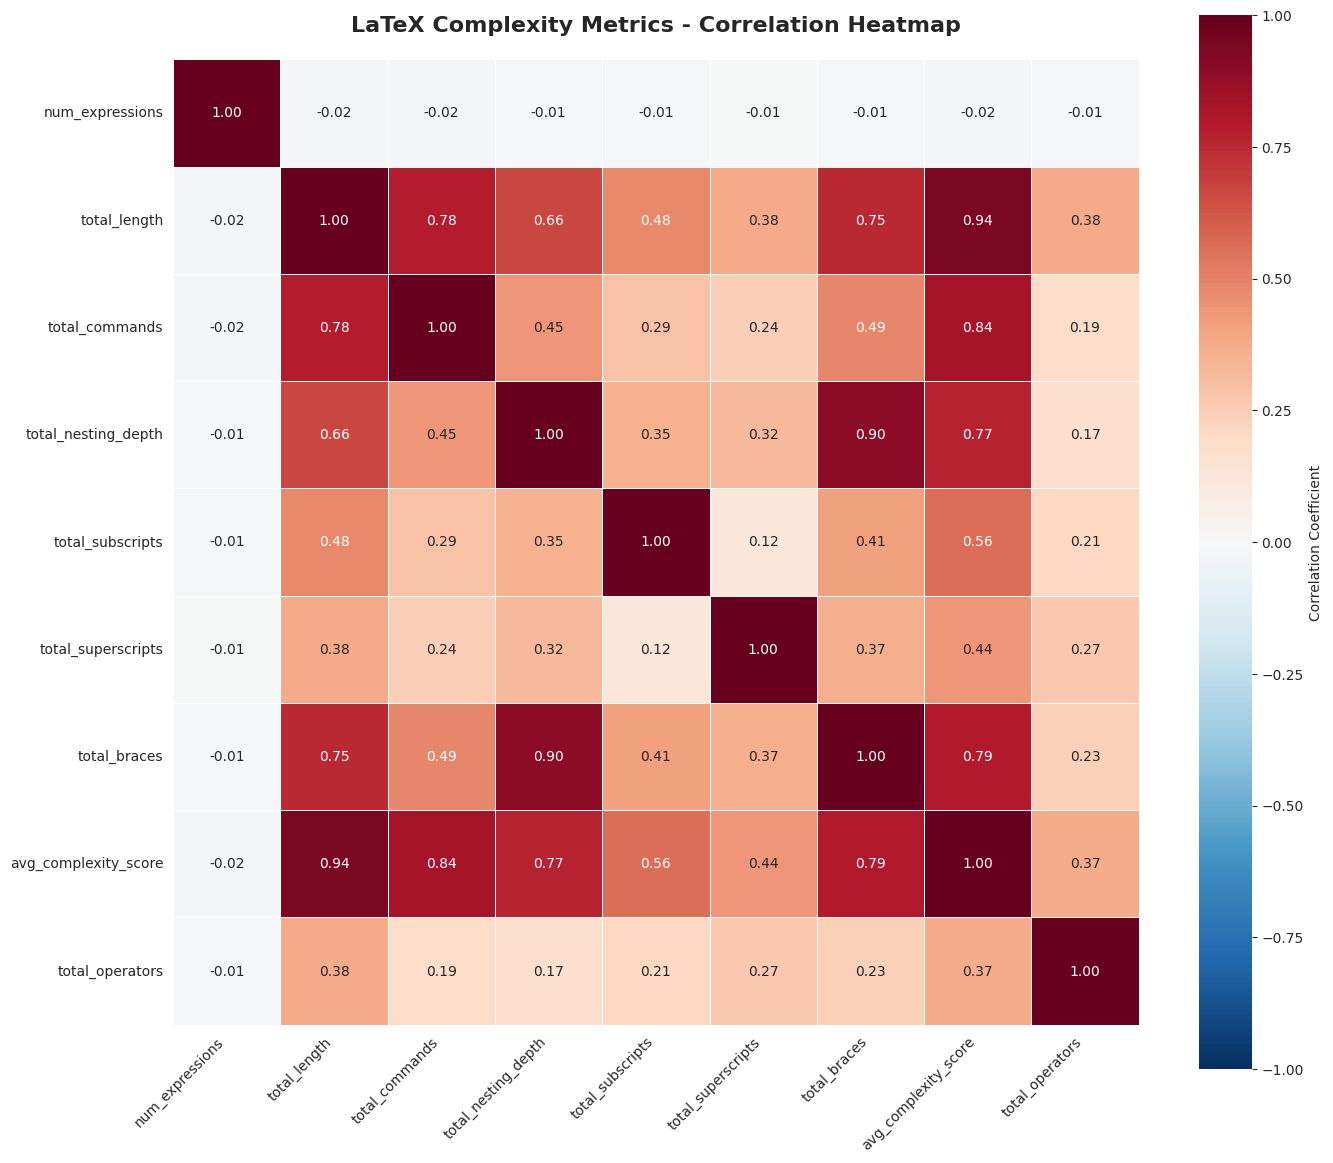

✓ Correlation heatmap saved as 'latex_complexity_correlation_heatmap.png'


In [9]:
plot_latex_complexity_correlation(df_2)

Original shape: (23195831, 9)
Columns: ['latex_num_expressions', 'latex_total_length', 'latex_total_commands', 'latex_total_nesting_depth', 'latex_total_subscripts', 'latex_total_superscripts', 'latex_total_braces', 'latex_avg_complexity_score', 'latex_total_operators']

PCA ANALYSIS RESULTS

Explained Variance Ratio:
  PC1: 0.5073 (50.73%)
  PC2: 0.1111 (11.11%)

Cumulative Explained Variance: 0.6184 (61.84%)

Principal Components (Loadings):
                           PC1       PC2
num_expressions      -0.011199  0.982848
total_length          0.436844  0.000265
total_commands        0.355315  0.012363
total_nesting_depth   0.383169  0.066553
total_subscripts      0.264055  0.002472
total_superscripts    0.227777 -0.070378
total_braces          0.406310  0.054713
avg_complexity_score  0.461023  0.004808
total_operators       0.191669 -0.146461



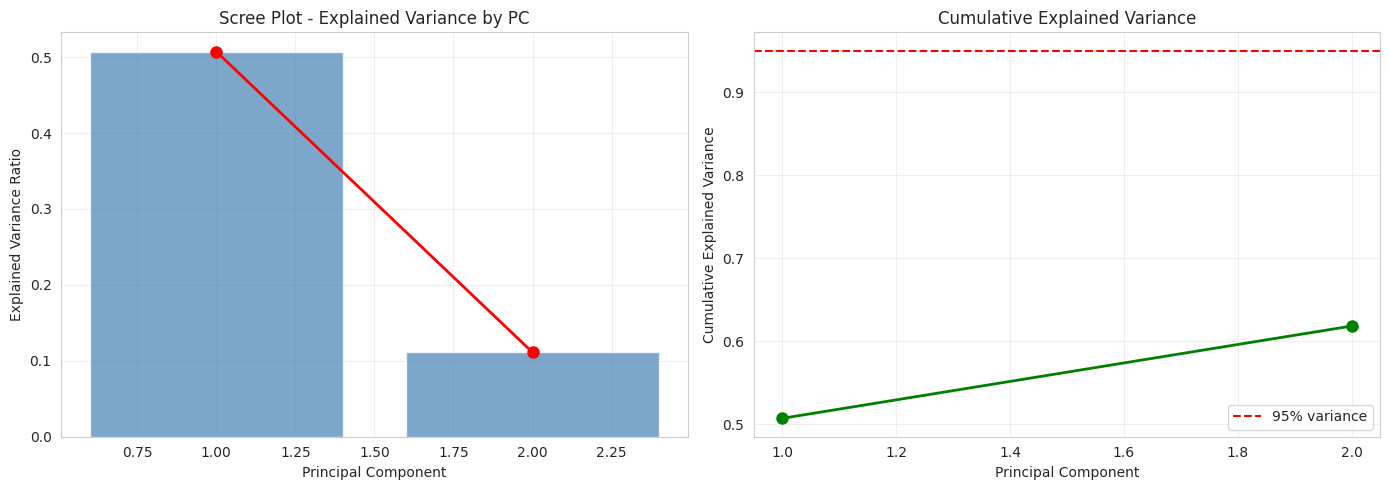

✓ Saved 'pca_explained_variance.png'

New PCA columns added:
              pca_1         pca_2
count  2.319583e+07  2.319583e+07
mean  -4.136592e-18 -1.211571e-17
std    2.136742e+00  1.000124e+00
min   -2.949360e+00 -5.349625e+00
25%   -1.532067e+00 -1.481389e-02
50%   -8.499489e-01 -1.448202e-02
75%    5.797396e-01  1.563081e-03
max    1.985223e+01  1.694105e+02

First 5 rows:
                                equation     pca_1     pca_2
0                                $ 1/R $ -0.988066 -0.295917
1                                  $ m $ -1.532067 -0.014814
2  $ |B ( p_B ) \rangle\to |p_b\rangle $  2.840141  0.044494
3                           $ \epsilon $ -0.582959  0.001397
4                $ j^ * ( \gamma ) = 0 $  1.679208 -0.763526


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def apply_pca_to_latex_metrics(df, n_components=2, plot=True):
    """
    Apply PCA to reduce 9 LaTeX complexity columns to 2 principal components.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original dataframe with latex_* columns
    n_components : int
        Number of components (default: 2)
    plot : bool
        Whether to plot the explained variance and PCA space
    
    Returns:
    --------
    df : pandas.DataFrame
        DataFrame with PCA1 and PCA2 columns added
    pca : PCA object
        Fitted PCA object
    scaler : StandardScaler object
        Fitted scaler for future transformations
    """
    
    # Get LaTeX columns
    latex_cols = [col for col in df.columns if col.startswith('latex_')]
    X = df[latex_cols].copy()
    
    # Handle missing values
    X = X.fillna(X.mean())
    
    print(f"Original shape: {X.shape}")
    print(f"Columns: {latex_cols}\n")
    
    # Standardize the features (CRITICAL for PCA)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_scaled)
    
    # Add PCA columns to dataframe
    df['pca_1'] = X_pca[:, 0]
    df['pca_2'] = X_pca[:, 1]
    
    # Print information
    print("="*100)
    print("PCA ANALYSIS RESULTS")
    print("="*100)
    print(f"\nExplained Variance Ratio:")
    for i, var in enumerate(pca.explained_variance_ratio_):
        print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")
    
    print(f"\nCumulative Explained Variance: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")
    
    print(f"\nPrincipal Components (Loadings):")
    loadings_df = pd.DataFrame(
        pca.components_.T,
        columns=[f'PC{i+1}' for i in range(n_components)],
        index=[col.replace('latex_', '') for col in latex_cols]
    )
    print(loadings_df.to_string())
    
    print("\n" + "="*100)
    
    # Plot explained variance
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Scree plot
        axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
                    pca.explained_variance_ratio_, alpha=0.7, color='steelblue')
        axes[0].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                     pca.explained_variance_ratio_, 'ro-', linewidth=2, markersize=8)
        axes[0].set_xlabel('Principal Component')
        axes[0].set_ylabel('Explained Variance Ratio')
        axes[0].set_title('Scree Plot - Explained Variance by PC')
        axes[0].grid(True, alpha=0.3)
        
        # Cumulative variance
        cumsum = np.cumsum(pca.explained_variance_ratio_)
        axes[1].plot(range(1, len(cumsum) + 1), cumsum, 'go-', linewidth=2, markersize=8)
        axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
        axes[1].set_xlabel('Principal Component')
        axes[1].set_ylabel('Cumulative Explained Variance')
        axes[1].set_title('Cumulative Explained Variance')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('pca_explained_variance.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("✓ Saved 'pca_explained_variance.png'")
    
    return df, pca, scaler

# Usage
df, pca, scaler = apply_pca_to_latex_metrics(df_2, n_components=2, plot=True)

# Check new columns
print("\nNew PCA columns added:")
print(df[['pca_1', 'pca_2']].describe())
print("\nFirst 5 rows:")
print(df[['equation', 'pca_1', 'pca_2']].head())

In [11]:
# def plot_pca_space(df, sample_col='pca_1', color_by='latex_avg_complexity_score', figsize=(12, 8)):
#     """
#     Plot the PCA space with optional coloring.
#     """
    
#     fig, ax = plt.subplots(figsize=figsize)
    
#     scatter = ax.scatter(df['pca_1'], df['pca_2'], 
#                         c=df[color_by], 
#                         cmap='viridis', 
#                         alpha=0.6, 
#                         s=50,
#                         edgecolors='black', 
#                         linewidth=0.5)
    
#     ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=12)
#     ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=12)
#     ax.set_title('PCA Space of LaTeX Complexity Metrics', fontsize=14, fontweight='bold')
#     ax.grid(True, alpha=0.3)
    
#     cbar = plt.colorbar(scatter, ax=ax)
#     cbar.set_label(color_by.replace('latex_', ''), fontsize=11)
    
#     plt.tight_layout()
#     plt.savefig('pca_space.png', dpi=300, bbox_inches='tight')
#     plt.show()
#     print("✓ Saved 'pca_space.png'")

# # Usage
# plot_pca_space(df, color_by='latex_avg_complexity_score')

In [12]:
def create_stratified_samples_pca(df, sample_sizes=[2000, 4000, 8000, 16000, 32000, 64000]):
    """
    Create stratified samples using PCA components.
    """
    
    samples = {}
    
    # Create stratification based on PCA components
    df_temp = df.copy()
    
    # Create stratification column properly
    pca1_cat = pd.cut(
        df_temp['pca_1'], 
        bins=2, 
        labels=['PCA1_Low', 'PCA1_High'],
        duplicates='drop'
    ).astype(str)
    
    pca2_cat = pd.cut(
        df_temp['pca_2'], 
        bins=2, 
        labels=['PCA2_Low', 'PCA2_High'],
        duplicates='drop'
    ).astype(str)
    
    # Combine them correctly
    df_temp['_pca_quadrant'] = pca1_cat + '_' + pca2_cat
    
    for size in sample_sizes:
        if size > len(df):
            print(f"⚠️  Sample size {size} > dataframe size. Using full dataframe.")
            samples[f'df_{size}'] = df.copy()
            continue
        
        # Stratified sample
        sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(
            lambda x: x.sample(n=max(1, int(len(x) * size / len(df_temp))), random_state=42)
        )
        
        # Adjust to exact size
        if len(sampled_df) > size:
            sampled_df = sampled_df.sample(n=size, random_state=42)
        elif len(sampled_df) < size:
            missing = size - len(sampled_df)
            additional = df_temp.sample(n=missing, random_state=42)
            sampled_df = pd.concat([sampled_df, additional], ignore_index=True)
        
        # Remove temporary column
        sampled_df = sampled_df.drop('_pca_quadrant', axis=1)
        samples[f'df_{size}'] = sampled_df.reset_index(drop=True)
        
        print(f"✓ Created df_{size} with {len(sampled_df)} samples")
    
    return samples

# Usage
sample_dfs = create_stratified_samples_pca(df, sample_sizes=[2000, 4000, 8000, 16000, 32000, 64000])

/tmp/ipykernel_39184/2631393635.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(


✓ Created df_2000 with 2000 samples


/tmp/ipykernel_39184/2631393635.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(


✓ Created df_4000 with 4000 samples


/tmp/ipykernel_39184/2631393635.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(


...

✓ Created df_16000 with 16000 samples


/tmp/ipykernel_39184/2631393635.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(


✓ Created df_32000 with 32000 samples


/tmp/ipykernel_39184/2631393635.py:36: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_df = df_temp.groupby('_pca_quadrant', group_keys=False).apply(


✓ Created df_64000 with 64000 samples


/tmp/ipykernel_39184/1175161610.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipykernel_39184/1175161610.py:24: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('pca_sample_comparison.png', dpi=300, bbox_inches='tight')
/opt/python/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


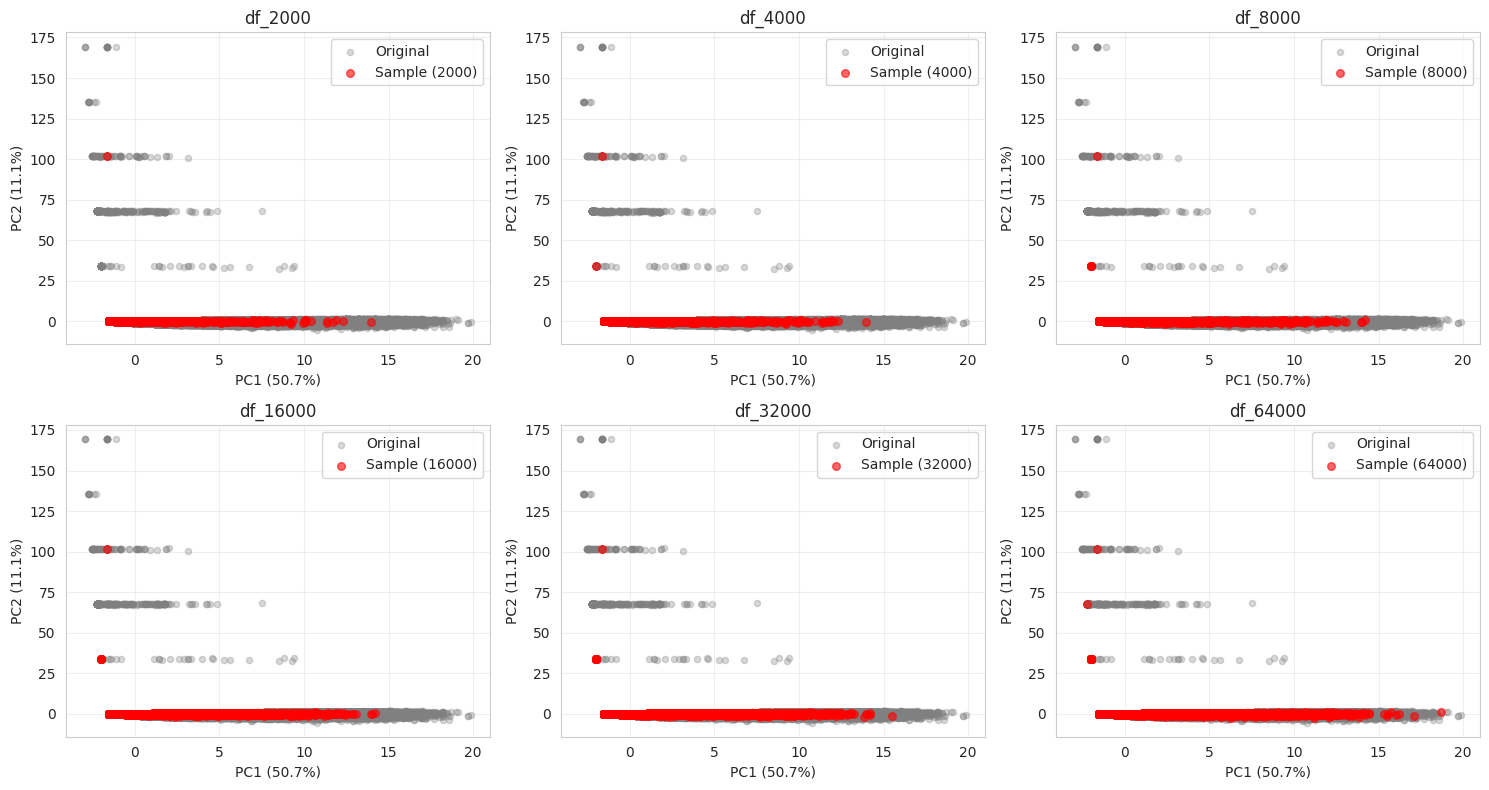

✓ Saved 'pca_sample_comparison.png'


In [13]:
def compare_pca_distributions(original_df, sample_dfs):
    """
    Compare PCA distributions between original and samples.
    """
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, (key, df_sample) in enumerate(sample_dfs.items()):
        ax = axes[idx]
        
        ax.scatter(original_df['pca_1'], original_df['pca_2'], 
                  alpha=0.3, s=20, label='Original', color='gray')
        ax.scatter(df_sample['pca_1'], df_sample['pca_2'], 
                  alpha=0.6, s=30, label=f'Sample ({len(df_sample)})', color='red')
        
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
        ax.set_title(key)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('pca_sample_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Saved 'pca_sample_comparison.png'")

# Usage
compare_pca_distributions(df, sample_dfs)

In [17]:
import os

def save_sample_dfs_to_csv(sample_dfs, output_dir='samples'):
    """
    Verify that all values in sample_dfs are dataframes and save them to CSV.
    
    Parameters:
    -----------
    sample_dfs : dict
        Dictionary where keys are df names and values are dataframes
    output_dir : str
        Directory where CSV files will be saved
    
    Returns:
    --------
    bool : True if all files saved successfully
    """
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Check if sample_dfs is a dictionary
    if not isinstance(sample_dfs, dict):
        print(f"❌ Error: sample_dfs is not a dictionary. Type: {type(sample_dfs)}")
        return False
    
    print(f"Found {len(sample_dfs)} items in sample_dfs\n")
    
    # Verify each item and save
    successful = 0
    failed = 0
    
    for key, value in sample_dfs.items():
        # Check if value is a dataframe
        if not isinstance(value, pd.DataFrame):
            print(f"❌ {key}: NOT a dataframe. Type: {type(value)}")
            failed += 1
            continue
        
        # Check dataframe size
        rows, cols = value.shape
        print(f"✓ {key}: Valid dataframe ({rows} rows, {cols} columns)")
        
        # Save to CSV
        filepath = os.path.join(output_dir, f'{key}.csv')
        value.to_csv(filepath, index=False)
        print(f"  → Saved to: {filepath}\n")
        successful += 1
    
    # Summary
    print("="*80)
    print(f"SUMMARY: {successful} files saved successfully, {failed} files failed")
    print(f"Output directory: {os.path.abspath(output_dir)}")
    print("="*80)
    
    return failed == 0

# Usage
success = save_sample_dfs_to_csv(sample_dfs, output_dir='samples')

if success:
    print("\n✓ All dataframes saved successfully!")
else:
    print("\n⚠️ Some errors occurred. Check the output above.")

Found 6 items in sample_dfs

✓ df_2000: Valid dataframe (2000 rows, 15 columns)
  → Saved to: samples/df_2000.csv

✓ df_4000: Valid dataframe (4000 rows, 15 columns)
  → Saved to: samples/df_4000.csv

✓ df_8000: Valid dataframe (8000 rows, 15 columns)
  → Saved to: samples/df_8000.csv

✓ df_16000: Valid dataframe (16000 rows, 15 columns)


  → Saved to: samples/df_16000.csv

✓ df_32000: Valid dataframe (32000 rows, 15 columns)
  → Saved to: samples/df_32000.csv

✓ df_64000: Valid dataframe (64000 rows, 15 columns)
  → Saved to: samples/df_64000.csv

SUMMARY: 6 files saved successfully, 0 files failed
Output directory: /home/onyxia/work/StatAppV2/samples

✓ All dataframes saved successfully!
